## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR, TRAJECTORY_CMAP

## Functions

In [2]:
def draw_episode_underlay(ax):
    """Draw the episode event-path underneath a recall event-path"""
    ax.plot(atlep1.path_2d[:, 0], 
            atlep1.path_2d[:, 1],
            color=EPISODE_UNDERLAY_COLOR,
            alpha=EPISODE_UNDERLAY_ALPHA,
            linewidth=EPISODE_UNDERLAY_LINEWIDTH,
            linestyle=EPISODE_UNDERLAY_LINESTYLE,
            zorder=0)
    return ax

In [3]:
def draw_events_path(
    ax, 
    events_2d, 
    colors, 
    event_markersize, 
    connection_linewidth, 
    event_border_linewidth
):
    """Draw a single recall event-path"""
    ax.plot(events_2d[:, 0], 
            events_2d[:, 1], 
            color=CONNECTION_LINE_COLOR, 
            linewidth=connection_linewidth, 
            zorder=1)
    ax.scatter(events_2d[:, 0], 
               events_2d[:, 1], 
               s=event_markersize, 
               c=colors,
               cmap=None,
               edgecolors=EVENT_BORDER_COLOR, 
               linewidths=event_border_linewidth, 
               zorder=2)
    return ax

In [4]:
def set_axes_limits(ax, path, aspect=1):
    """
    Frame a panel's axes to a square centered on its path with padding.
    """
    (x_min, y_min), (x_max, y_max) = path.min(axis=0), path.max(axis=0)
    x_center, y_center = (x_min + x_max) / 2, (y_min + y_max) / 2
    x_range = (x_max - x_min) * (1 + DATA_BOUNDS_MARGIN)
    y_range = (y_max - y_min) * (1 + DATA_BOUNDS_MARGIN)
    if x_range / y_range > aspect:
        y_range = x_range / aspect
    else:
        x_range = y_range * aspect
    ax.set_xlim(x_center - x_range / 2, x_center + x_range / 2)
    ax.set_ylim(y_center - y_range / 2, y_center + y_range / 2)
    ax.set_aspect('equal')
    ax.axis('off')
    return ax

In [5]:
def panel_units_to_rect(x, y_top, w, h, fig_width, fig_height):
    """
    Convert a panel's (x, y, width, height) box in panel units to 
    fractions of full figure height/width.
    """
    return [x / fig_width, 
            (fig_height - y_top - h) / fig_height, 
            w / fig_width, 
            h / fig_height]

## Load data

In [6]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

## Construct figure

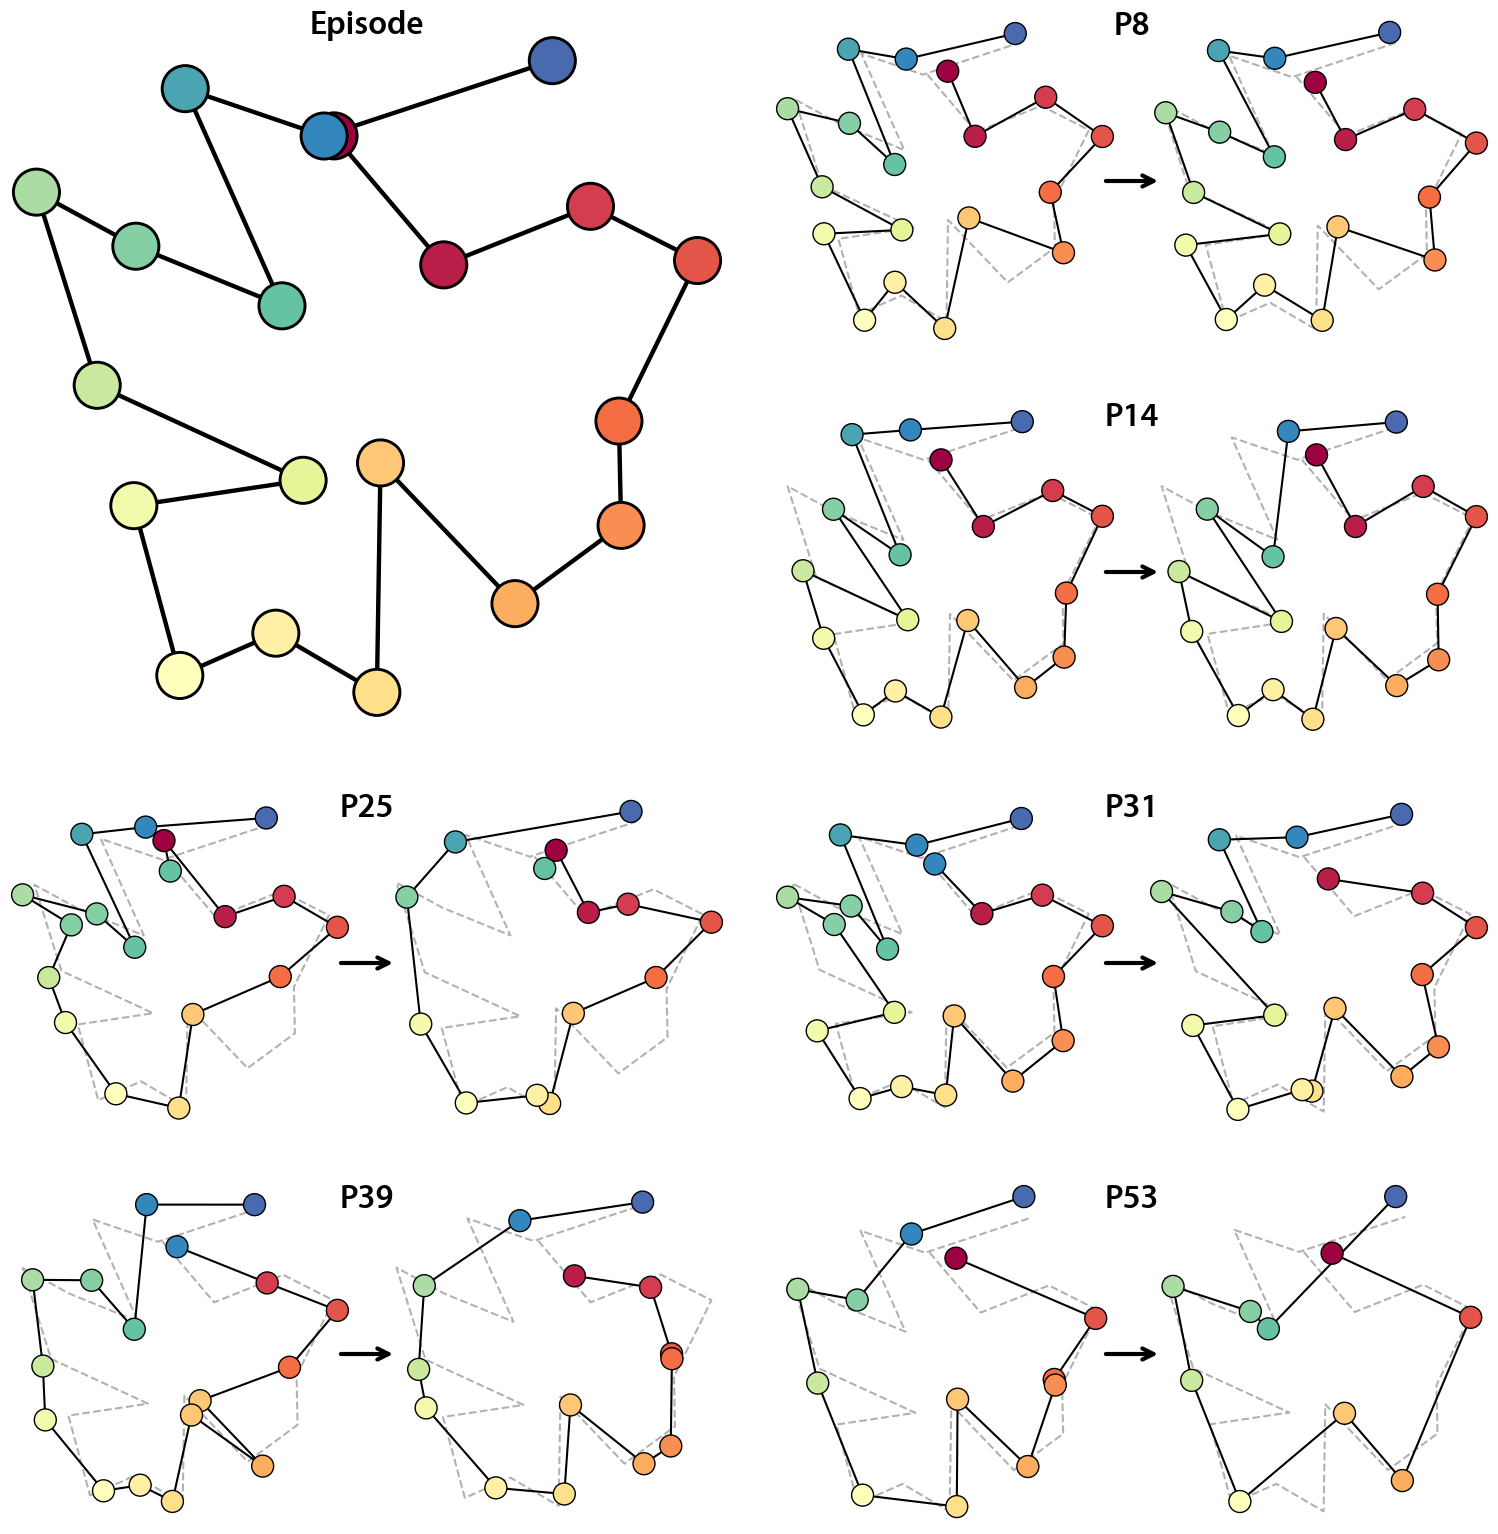

In [7]:
################################ CONFIG ################################

# shared (RECALL_-prefixed values are scaled up for episode)
RECALL_EVENT_MARKERSIZE = 250
RECALL_EVENT_BORDER_LINEWIDTH = 1
EVENT_BORDER_COLOR = 'k'
RECALL_CONNECTION_LINEWIDTH = 1.5
CONNECTION_LINE_COLOR = 'k'
DATA_BOUNDS_MARGIN = 0.08
TITLE_FONTSIZE = 24
TITLE_FONTWEIGHT = 'semibold'

# recall-specific
EXAMPLE_PARTICIPANT_NS = (8, 14, 25, 31, 39, 53)
EPISODE_UNDERLAY_COLOR = 'k'
EPISODE_UNDERLAY_ALPHA = 0.3
EPISODE_UNDERLAY_LINEWIDTH = RECALL_CONNECTION_LINEWIDTH
EPISODE_UNDERLAY_LINESTYLE = '--'

# immediate -> delayed recall arrows
PAIR_ARROW_COLOR = 'k'
PAIR_ARROW_LINEWIDTH = 3
PAIR_ARROW_HEAD_SCALE = 20
PAIR_ARROW_LENGTH_FRAC = 1.7

# grid layout
N_ROWS = 4
N_COLS = 4
EPISODE_N_ROWS = 2
EPISODE_N_COLS = 2
RECALL_PANEL_SIZE_INCHES = 3.4
WITHIN_PAIR_GAP = 0.1
BETWEEN_PAIR_GAP = 0.15
ROW_GAP = 0.15


########################################################################

# =========================== derived values ===========================


# scaling for episode panel
EPISODE_PANEL_WIDTH = EPISODE_N_COLS + WITHIN_PAIR_GAP
EPISODE_PANEL_HEIGHT = EPISODE_N_ROWS + ROW_GAP
EPISODE_SCALE = EPISODE_PANEL_WIDTH
EPISODE_EVENT_MARKERSIZE = RECALL_EVENT_MARKERSIZE * EPISODE_SCALE ** 2
EPISODE_EVENT_BORDER_LINEWIDTH = RECALL_EVENT_BORDER_LINEWIDTH * EPISODE_SCALE
EPISODE_CONNECTION_LINEWIDTH = RECALL_CONNECTION_LINEWIDTH * EPISODE_SCALE

# location of each column's left edge, in panel units
col_xs = []
for col_ix in range(N_COLS):
    col_left = (col_ix + 
                WITHIN_PAIR_GAP * ((col_ix + 1) // 2) + 
                BETWEEN_PAIR_GAP * (col_ix // 2))
    col_xs.append(col_left)

# location of each row's top edge, in panel units
row_ys = []
for row_ix in range(N_ROWS):
    row_ys.append(row_ix + (row_ix + 1) * ROW_GAP)
    
fig_width = (N_COLS + 
             WITHIN_PAIR_GAP * (N_COLS // 2) + 
             BETWEEN_PAIR_GAP * (N_COLS // 2 - 1))
fig_height = N_ROWS * (1 + ROW_GAP)


example_participants = [participants[n - 1] for n in EXAMPLE_PARTICIPANT_NS]
# row/col location of each participant's pair of paths
# (row, immediate col, delayed col)
PARTICIPANT_PLACEMENTS = [
    (row, 2 * block, 2 * block + 1)
    for row in range(N_ROWS)
    for block in range(N_COLS // 2)
    if not (row < EPISODE_N_ROWS and 2 * block < EPISODE_N_COLS)
]
assert len(EXAMPLE_PARTICIPANT_NS) == len(PARTICIPANT_PLACEMENTS)


# ========================== construct figure ==========================

fig = plt.figure(figsize=(fig_width * RECALL_PANEL_SIZE_INCHES, 
                          fig_height * RECALL_PANEL_SIZE_INCHES))
fig.patch.set_alpha(0)

episode_axes_rect = panel_units_to_rect(x=col_xs[0], 
                                        y_top=row_ys[0], 
                                        w=EPISODE_PANEL_WIDTH, 
                                        h=EPISODE_PANEL_HEIGHT, 
                                        fig_width=fig_width, 
                                        fig_height=fig_height)
episode_ax = fig.add_axes(episode_axes_rect)

recall_axes_pairs = []
for p, (row, imm_col, del_col) in zip(example_participants, PARTICIPANT_PLACEMENTS):
    y_top = row_ys[row]
    imm_axes_rect = panel_units_to_rect(x=col_xs[imm_col], 
                                        y_top=y_top,
                                        w=1, 
                                        h=1, 
                                        fig_width=fig_width, 
                                        fig_height=fig_height)
    imm_ax = fig.add_axes(imm_axes_rect)
    
    del_axes_rect = panel_units_to_rect(x=col_xs[del_col], 
                                        y_top=y_top,
                                        w=1, 
                                        h=1, 
                                        fig_width=fig_width, 
                                        fig_height=fig_height)
    del_ax = fig.add_axes(del_axes_rect)
    
    recall_axes_pairs.append((p, imm_ax, del_ax))


# ============================== episode ===============================

episode_event_colors = TRAJECTORY_CMAP(
    np.arange(len(atlep1.events)) / len(atlep1.events)
)
draw_events_path(episode_ax, 
                 atlep1.path_2d, 
                 colors=episode_event_colors, 
                 event_markersize=EPISODE_EVENT_MARKERSIZE, 
                 connection_linewidth=EPISODE_CONNECTION_LINEWIDTH, 
                 event_border_linewidth=EPISODE_EVENT_BORDER_LINEWIDTH)
set_axes_limits(episode_ax, 
                atlep1.path_2d, 
                aspect=EPISODE_PANEL_WIDTH / EPISODE_PANEL_HEIGHT)


for p, imm_ax, del_ax in recall_axes_pairs:
    
    # ====================== immediate recall ======================
    
    imm_event_colors = TRAJECTORY_CMAP(
        p.event_matches['atlep1'] / len(atlep1.events)
    )
    draw_episode_underlay(imm_ax)
    draw_events_path(imm_ax, 
                     p.paths_2d['atlep1'], 
                     colors=imm_event_colors, 
                     event_markersize=RECALL_EVENT_MARKERSIZE, 
                     connection_linewidth=RECALL_CONNECTION_LINEWIDTH, 
                     event_border_linewidth=RECALL_EVENT_BORDER_LINEWIDTH)
    set_axes_limits(imm_ax, np.vstack([p.paths_2d['atlep1'], atlep1.path_2d]))
    
    
    # ======================= delayed recall =======================
    
    del_event_colors = TRAJECTORY_CMAP(
        p.event_matches['delayed'] / len(atlep1.events)
    )
    draw_episode_underlay(del_ax)
    draw_events_path(del_ax, 
                     p.paths_2d['delayed'], 
                     colors=del_event_colors, 
                     event_markersize=RECALL_EVENT_MARKERSIZE, 
                     connection_linewidth=RECALL_CONNECTION_LINEWIDTH, 
                     event_border_linewidth=RECALL_EVENT_BORDER_LINEWIDTH)
    set_axes_limits(del_ax, np.vstack([p.paths_2d['delayed'], atlep1.path_2d]))
    

# =================== axes pair titles & arrows ====================

episode_ax.set_title('Episode', 
                     va='top', 
                     y=0.99, 
                     fontsize=TITLE_FONTSIZE, 
                     fontweight=TITLE_FONTWEIGHT)

fig.canvas.draw()

for p, imm_ax, del_ax in recall_axes_pairs:
    box_imm, box_del = imm_ax.get_position(), del_ax.get_position()
    x_center = (box_imm.x0 + box_del.x1) / 2
    y_top = max(box_imm.y1, box_del.y1)
    fig.text(x_center, 
             y_top, 
             f'P{p.sub_n}',
             ha='center', 
             va='top',
             fontsize=TITLE_FONTSIZE, 
             fontweight='semibold')
    
    y_middle = (box_imm.y0 + box_imm.y1) / 2
    gap_center = (box_imm.x1 + box_del.x0) / 2
    half_len = (box_del.x0 - box_imm.x1) * PAIR_ARROW_LENGTH_FRAC / 2
    arrow = FancyArrowPatch((gap_center - half_len, y_middle), 
                            (gap_center + half_len, y_middle),
                            arrowstyle='->',
                            color=PAIR_ARROW_COLOR, 
                            mutation_scale=PAIR_ARROW_HEAD_SCALE, 
                            linewidth=PAIR_ARROW_LINEWIDTH,
                            transform=fig.transFigure, 
                            clip_on=False)
    fig.add_artist(arrow)
    
# plt.savefig(FIG_DIR / '2d-trajectories.pdf', bbox_inches='tight')
plt.show()